# Inferential Statistics Project

## Objective
To apply inferential statistical techniques on a health dataset and analyze factors affecting diseases.

## Theory
### Inferential Statistics
Inferential statistics is about making predictions or inferences about a population, based on sample data. You take a small portion, analyze it, and then draw conclusions about the whole group. 

### Hypothesis Testing
1. Hypotheses

A hypothesis is a statement about a population parameter.

Null Hypothesis (H₀)
The default assumption.
Usually states that there is no effect, no difference, or no change.

Example:

H₀: The average life of the bulb is 1,000 hours.
Alternative Hypothesis (H₁ or Hₐ)
The claim you want to test.
States that there is an effect, difference, or change.

Example:

H₁: The average life of the bulb is not 1,000 hours.

**H₀:** Smoking has no effect on Diabetes.  
**H₁:** Smoking affects Diabetes.

**H₀:** Mean Blood Pressure of males and females is equal.  
**H₁:** Mean Blood Pressure of males and females is different.


### Confidence Interval
A range of values likely to contain the true population parameter.

### P-value
The p-value is the probability of obtaining the observed result, or a more extreme result, assuming that the null hypothesis (H₀) is true.
- p-value < 0.05 → Reject H₀
- p-value > 0.05 → Fail to Reject H₀

### Type I Error
Rejecting a true null hypothesis.

### Type II Error
Failing to reject a false null hypothesis.

### Brief Description of Statistical Tests

1. Z-Test (often written as Z-test, not "jet test")

Used to compare sample and population means when the sample size is large (n > 30) or population standard deviation is known.
Example: Checking whether the average height of students differs from a known population average.

2. T-Test

Used to compare means when the sample size is small (n ≤ 30) and population standard deviation is unknown.
Example: Comparing the average marks of two small groups of students.

3. Chi-Square (χ²) Test

Used to test the association between categorical variables or to check goodness of fit.
Example: Determining whether gender and product preference are related.

4. ANOVA (Analysis of Variance)

Used to compare the means of three or more groups simultaneously.
Example: Comparing the average performance of students taught by three different teaching methods.

### T-Test
Compares the means of two groups.

### Chi-Square Test
Checks the relationship between categorical variables.

### ANOVA
Compares means of more than two groups.

### Covariance
Definition:
Covariance is a statistical measure that indicates the direction of the relationship between two variables.

Interpretation:
Positive Covariance: Both variables tend to increase or decrease together.
Negative Covariance: One variable increases while the other decreases.
Zero Covariance: No linear relationship between the variables.

### Correlation
Definition:
Correlation is a statistical measure that indicates the strength and direction of the relationship between two variables.

Types:
Positive Correlation (+): Both variables move in the same direction.
Negative Correlation (−): Variables move in opposite directions.
Zero Correlation (0): No relationship between variables.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import t
from scipy.stats import chi2
from scipy.stats import f

df = pd.read_csv("health_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (500, 15)


,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,a46029e8-9eb6-4792-aff6-08595e05ae87,46-60,56,68,Male,South,Non-Smoker,Daily,28.2,126.2,False,False,202.0,110.1,2026-04-17
1,7b28e913-5fd1-4fd9-8f36-ff34549548d9,36-45,38,104,Female,East,Non-Smoker,Weekly,26.1,120.9,False,True,207.2,97.5,2025-05-26
2,afef95bb-5f57-4d14-b59c-db835a064e06,60+,61,83,Female,West,Non-Smoker,Daily,23.8,135.5,False,True,204.6,116.1,2024-11-06
3,dff77c9f-0352-482a-9733-706838b70088,36-45,37,80,Female,West,Smoker,Never,29.8,145.6,False,True,206.4,79.1,2026-01-28
4,f38e379c-bae1-45df-9655-bead976b95e7,46-60,59,59,Female,South,Non-Smoker,Rarely,17.3,123.2,False,False,226.7,119.9,2025-08-17


## Confidence Interval for Age

In [3]:
mean_age = df["age"].mean()
std_age = df["age"].std()

n = len(df)

margin = 1.96 * (std_age / np.sqrt(n))

lower = mean_age - margin
upper = mean_age + margin

print("Mean Age =", mean_age)
print("95% Confidence Interval =", lower, "to", upper)

Mean Age = 43.668
95% Confidence Interval = 42.37864017789256 to 44.95735982210744


### Interpretation
The 95% confidence interval provides a range in which the true average age of the population is likely to fall.

## T-Test: Male vs Female Blood Pressure

In [4]:
male_bp = df[df["gender"]=="Male"]["blood_pressure"]

female_bp = df[df["gender"]=="Female"]["blood_pressure"]

t_stat, p_value = ttest_ind(male_bp, female_bp)

print("T Statistic =", t_stat)
print("P Value =", p_value)

alpha = 0.05

dfree = len(male_bp) + len(female_bp) - 2

critical_t = t.ppf(1 - alpha/2, dfree)

print("Critical Value =", critical_t)

if p_value < 0.05:
    print("Decision by P Value: Reject H0")
else:
    print("Decision by P Value: Fail to Reject H0")

if abs(t_stat) > critical_t:
    print("Decision by Critical Value: Reject H0")
else:
    print("Decision by Critical Value: Fail to Reject H0")

T Statistic = 1.997127853808776
P Value = 0.0463549683256648
Critical Value = 1.9647389829672888
Decision by P Value: Reject H0
Decision by Critical Value: Reject H0


### Interpretation
This test compares blood pressure between males and females.

## Chi-Square Test: Smoking vs Diabetes

In [5]:
table = pd.crosstab(
    df["smoking_status"],
    df["diabetes"]
)

print(table)

chi_square_stat, p, dof, expected = chi2_contingency(table)

print("Chi Square =", chi_square_stat)

print("P Value =", p)

critical_chi = chi2.ppf(
    0.95,
    dof
)

print("Critical Value =", critical_chi)

if p < 0.05:
    print("Decision by P Value: Reject H0")
else:
    print("Decision by P Value: Fail to Reject H0")

if chi_square_stat > critical_chi:
    print("Decision by Critical Value: Reject H0")
else:
    print("Decision by Critical Value: Fail to Reject H0")

diabetes        False  True 
smoking_status              
Former Smoker      81     18
Non-Smoker        202     52
Smoker            104     43
Chi Square = 5.480253461976985
P Value = 0.06456216434778139
Critical Value = 5.991464547107979
Decision by P Value: Fail to Reject H0
Decision by Critical Value: Fail to Reject H0


### Interpretation
This test checks whether smoking status and diabetes are related.

## ANOVA: Blood Pressure Across Age Groups

In [6]:
g1 = df[df["age_group"]=="18-25"]["blood_pressure"]

g2 = df[df["age_group"]=="26-35"]["blood_pressure"]

g3 = df[df["age_group"]=="36-45"]["blood_pressure"]

g4 = df[df["age_group"]=="46-60"]["blood_pressure"]

g5 = df[df["age_group"]=="60+"]["blood_pressure"]

f_stat, p_value = f_oneway(
    g1,
    g2,
    g3,
    g4,
    g5
)

print("F Statistic =", f_stat)

print("P Value =", p_value)

df_between = 4
df_within = len(df) - 5

critical_f = f.ppf(
    0.95,
    df_between,
    df_within
)

print("Critical Value =", critical_f)

if p_value < 0.05:
    print("Decision by P Value: Reject H0")
else:
    print("Decision by P Value: Fail to Reject H0")

if f_stat > critical_f:
    print("Decision by Critical Value: Reject H0")
else:
    print("Decision by Critical Value: Fail to Reject H0")

F Statistic = 36.546319770010896
P Value = 8.820317151262241e-27
Critical Value = 2.389947844458197
Decision by P Value: Reject H0
Decision by Critical Value: Reject H0


### Interpretation
This test checks whether blood pressure differs among age groups.

## Covariance and Correlation

In [7]:
covariance = df["age"].cov(df["bmi"])

correlation = df["age"].corr(df["bmi"])

print("Covariance =", covariance)

print("Correlation =", correlation)

Covariance = 3.891951102204407
Correlation = 0.06499642489041312


### Interpretation
Positive values indicate a positive relationship, while negative values indicate a negative relationship.

## Charts

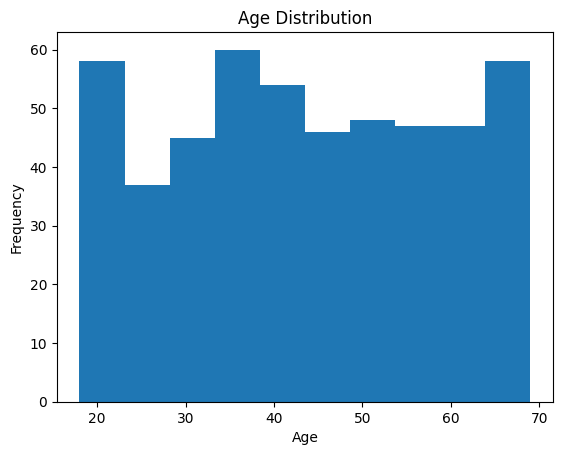

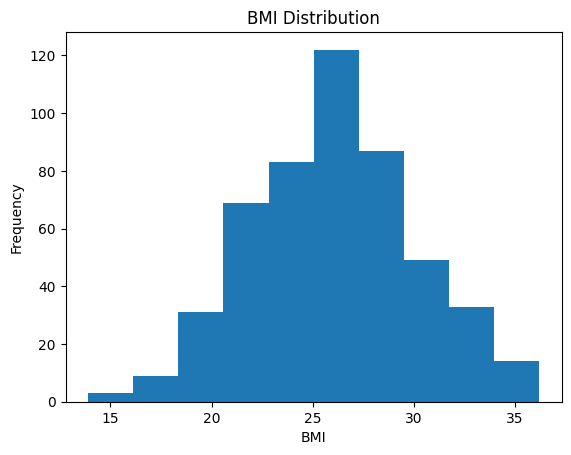

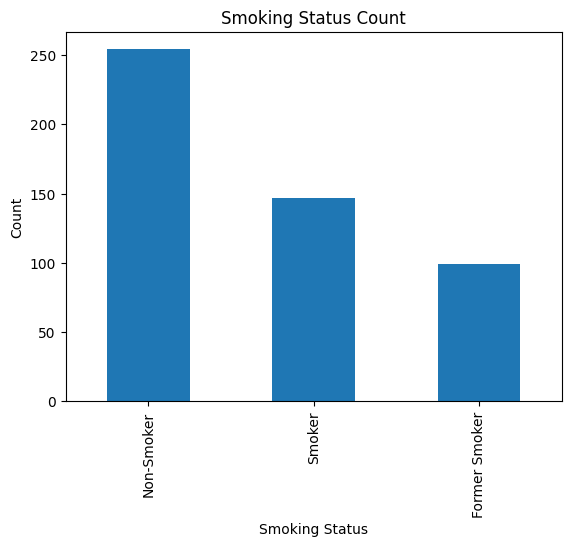

In [8]:
plt.hist(df["age"])

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()


plt.hist(df["bmi"])

plt.title("BMI Distribution")

plt.xlabel("BMI")

plt.ylabel("Frequency")

plt.show()


df["smoking_status"].value_counts().plot(kind="bar")

plt.title("Smoking Status Count")

plt.xlabel("Smoking Status")

plt.ylabel("Count")

plt.show()

### Chart Interpretation

The charts show the distribution of age, BMI and smoking status in the dataset.

# Final Conclusion

1. Confidence Interval was calculated for Age.
2. T-Test compared Blood Pressure between males and females.
3. Critical Values and P-Values were calculated.
4. Chi-Square Test analyzed Smoking and Diabetes.
5. ANOVA compared Blood Pressure among Age Groups.
6. Covariance and Correlation were calculated between Age and BMI.
7. Graphs were created for Age, BMI and Smoking Status.